# Task 2.1 Notebook 2: Feature selection with class imbalance

**Goal.** Start from the 535 DEGs in Notebook 1. Select a smaller set of genes that help
separate disease and control. We use four methods from Midterm 1 (MI, RFECV, Elastic Net,
GBC) and then a consensus vote.

**SMOTE** is used only on the **training** split. Midterm 1 used random undersampling for
breast cancer. Here the IBD split is 172 vs 22, so we keep all disease samples in train.

The official Midterm 1 panel (8 breast-cancer genes) is a **reference**. We do not re-run
that pipeline. Zero overlap with IBD candidates is expected because the disease is different.


## Key terms used in this notebook

| Term | Simple explanation |
| ---- | ------------------ |
| Feature | Here, one gene used as an input to a model. |
| Feature selection | Choosing a smaller gene list that still helps prediction. |
| MI / Mutual Information | How much a gene tells us about the class label. Higher can mean better separation. |
| RFECV | Recursive Feature Elimination with Cross-Validation. Removes weaker genes step by step. |
| Support | `True` means RFECV kept the gene in its final supported set. |
| Ranking | Lower rank = kept longer / more important in RFE. |
| Elastic Net / EN | Regression with L1 + L2 penalties. Can shrink some gene weights to zero. |
| L1 regularization | Can set some coefficients to exactly zero (selection). |
| L2 regularization | Shrinks large coefficients. Helps when genes are correlated. |
| GBC | Gradient Boosting Classifier: many small trees, each tree tries to fix earlier errors. |
| Feature importance | How much a gene was used in the trees. This is not the same as biology. |
| SMOTE | Creates synthetic minority (control) samples **in training only**. |
| Class weight | Extra penalty when the model is wrong on the smaller class. |
| TOPN | How many top genes we take from each method (here 25) so the vote is fair. |
| Consensus / vote | Count how many methods selected a gene. |
| Discrimination | Ability to tell disease from control. A downregulated gene can still discriminate. |
| LDA | Linear Discriminant Analysis. A simple linear classifier. We use it as a **baseline in Notebook 3**, not as a fifth vote here, so the consensus panel does not change. |

**DGE vs feature selection.** DGE asks which genes have a significant expression change.
Feature selection asks which genes help predict the group. A gene can be a strong DEG but
weak for prediction, or useful in a model without being the strongest DEG.

```text
MI      → Top N genes
RFECV   → Top N ranked genes
EN      → Top N genes
GBC     → Top N genes
              ↓
         Consensus vote
              ↓
       Candidate panel
```


## 1. Setup and load the DEG matrix

In [1]:
# We load the DEG only matrix from Notebook 1. Rows are the 194 samples, columns are
# the 535 DEG genes plus the target. We work only on DEGs because they already passed
# the statistical filter, so feature selection starts from a clean and small set.
import warnings
warnings.filterwarnings("ignore")
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, OrderedDict
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
RNG = 42

OUT = pathlib.Path("../04_Analysis")
DATA = pathlib.Path("../01_Data")
FIG = OUT / "figures"
dm = pd.read_csv(OUT / "deg_matrix_2_1.csv")
y = dm["target"].values
X = dm.drop(columns=["target"])
genes = list(X.columns)
print("DEG matrix:", dm.shape)
print("Disease (1):", int((y == 1).sum()), " Control (0):", int((y == 0).sum()))
# Per-method list size for the vote / merged map (RFECV may keep more internally).
TOPN = 25
print("TOPN per method for merged/vote lists:", TOPN)


DEG matrix: (194, 536)
Disease (1): 172  Control (0): 22
TOPN per method for merged/vote lists: 25


We start with 194 samples and 535 DEG genes, and 172 vs 22 classes.
A model trained on this split can ignore controls. That is why we use SMOTE and class weights
later. This count is not yet a performance result.


## 2. Balance the classes with the teamwork techniques

In [2]:
# SMOTE on the training split only (never before the split, never on the held-out test).
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.20, stratify=y, random_state=RNG
)
sm = SMOTE(random_state=RNG, k_neighbors=5)
Xb, yb = sm.fit_resample(X_train, y_train)
print("Full data:", dict(Counter(y)))
print("Train before SMOTE:", dict(Counter(y_train)))
print("Train after SMOTE :", dict(Counter(yb)))
print("Held-out test (no SMOTE, not used for FS):", dict(Counter(y_test)))
Xs = StandardScaler().fit_transform(Xb)


Full data: {np.int64(1): 172, np.int64(0): 22}
Train before SMOTE: {np.int64(1): 137, np.int64(0): 18}
Train after SMOTE : {np.int64(1): 137, np.int64(0): 137}
Held-out test (no SMOTE, not used for FS): {np.int64(1): 35, np.int64(0): 4}


We first split train/test. SMOTE then grows the **training** control class only.
The test set is never SMOTEd and is not used to rank genes. Class weights are a second tool:
mistakes on the minority class cost more.

What we cannot conclude: SMOTE does not add real new patients. Synthetic points only help
the training step.


## 3. Feature selection method 1: Mutual Information

In [3]:
# Mutual information: keep TOPN genes and *display the whole list*.
mi = pd.Series(mutual_info_classif(Xb, yb, random_state=RNG), index=genes).sort_values(ascending=False)
mi_rank = mi.reset_index()
mi_rank.columns = ["gene", "MI"]
mi_rank["rank"] = range(1, len(mi_rank) + 1)
mi_sel = set(mi.head(TOPN).index)
print(f"MI top {TOPN} (read this list):")
display(mi_rank.head(TOPN).round(4))


MI top 25 (read this list):


,gene,MI,rank
0,PAQR5,0.5830,1
1,SLC6A14,0.5605,2
2,NAAA,0.5438,3
3,BACE2,0.5366,4
4,IFITM3,0.5358,5
5,MXRA5,0.5338,6
6,CNTFR,0.5330,7
7,SLC38A4,0.5314,8
8,COL15A1,0.5106,9
9,SLC22A5,0.5084,10


**Mutual Information** measures how much a gene tells us about the label.
A higher score suggests the gene may help distinguish disease from control. Some top MI
genes also had large logFC in Notebook 1. That is useful agreement, but MI is not a biology
proof.


## 4. Feature selection method 2: RFECV

In [4]:
# RFECV chooses how many genes are jointly useful (n_features_). That number can be
# large (e.g. 160). For the vote we still take TOPN by ranking so methods are comparable,
# but we *display the full RFECV support set* so you can read who was kept.
rfe = RFECV(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG),
    step=25, cv=StratifiedKFold(5, shuffle=True, random_state=RNG),
    scoring="roc_auc", min_features_to_select=10, n_jobs=1,
)
rfe.fit(Xs, yb)
rfe_rank = pd.Series(rfe.ranking_, index=genes).sort_values()
rfe_support = [g for g, keep in zip(genes, rfe.support_) if keep]
rfe_sel = set(rfe_rank.head(TOPN).index)

rfe_tbl = pd.DataFrame({
    "gene": rfe_rank.index,
    "ranking": rfe_rank.values,
    "in_rfecv_support": [g in set(rfe_support) for g in rfe_rank.index],
}).reset_index(drop=True)
rfe_tbl["rank_for_vote"] = range(1, len(rfe_tbl) + 1)

print("RFECV best n_features_ (CV):", int(rfe.n_features_))
print("RFECV support genes (read this list, can be >> TOPN):", len(rfe_support))
display(pd.DataFrame({"rfecv_support_gene": rfe_support}))
print(f"\nTop {TOPN} by RFECV ranking (used in merged / votes):")
display(rfe_tbl.head(TOPN))
print("\nFull RFECV ranking table (all DEG genes ranked):")
from task2_1_lib import save_and_show
save_and_show(rfe_tbl, OUT / "fs_rfecv_ranking_2_1.csv", index=False, title=None)


RFECV best n_features_ (CV): 160
RFECV support genes (read this list, can be >> TOPN): 160


,rfecv_support_gene
0,ACPP
1,ADAMTS9
2,ADGRF5
3,ADH6
4,ALDOC
...,...
155,VNN1
156,VNN2
157,VWF
158,WNT5A



Top 25 by RFECV ranking (used in merged / votes):


,gene,ranking,in_rfecv_support,rank_for_vote
0,ZG16B,1,True,1
1,WNT5A,1,True,2
2,ADH6,1,True,3
3,ALDOC,1,True,4
4,ANGPTL2,1,True,5
5,ANPEP,1,True,6
6,APOL1,1,True,7
7,APOBEC3B,1,True,8
8,TRHDE,1,True,9
9,TRIM22,1,True,10



Full RFECV ranking table (all DEG genes ranked):


,gene,ranking,in_rfecv_support,rank_for_vote
0,ZG16B,1,True,1
1,WNT5A,1,True,2
2,ADH6,1,True,3
3,ALDOC,1,True,4
4,ANGPTL2,1,True,5
...,...,...,...,...
530,TMEM63C,16,False,531
531,THY1,16,False,532
532,GDPD2,16,False,533
533,MMP7,16,False,534


Saved: ..\04_Analysis\fs_rfecv_ranking_2_1.csv


**RFECV** starts with many features and removes less useful ones step by step.
Cross-validation estimates how many features to keep (`n_features_`).

- **Support = True:** the gene is in the final RFECV set. That set can be large (for example 160).
- **Ranking:** a lower number means the gene was more important in this elimination process.

For the **consensus vote** we only use the top TOPN RFECV genes. This keeps MI, RFECV,
Elastic Net and GBC at a similar list size. The full support table is still shown so you
can read every RFECV gene.


## 5. Feature selection method 3: Elastic Net

In [5]:
# Elastic Net: rank by |coefficient|, show TOPN and count of non-zero genes.
en = LogisticRegression(
    penalty="elasticnet", solver="saga", l1_ratio=0.5, C=0.1,
    max_iter=5000, class_weight="balanced", random_state=RNG,
)
en.fit(Xs, yb)
en_abs = pd.Series(np.abs(en.coef_[0]), index=genes).sort_values(ascending=False)
en_tbl = en_abs.reset_index()
en_tbl.columns = ["gene", "abs_coef"]
en_tbl["nonzero"] = en_tbl["abs_coef"] > 1e-6
en_tbl["rank"] = range(1, len(en_tbl) + 1)
en_sel = set(en_abs.head(TOPN).index)
print("Non-zero Elastic Net genes:", int(en_tbl["nonzero"].sum()))
print(f"EN top {TOPN}:")
display(en_tbl.head(TOPN).round(6))


Non-zero Elastic Net genes: 58
EN top 25:


,gene,abs_coef,nonzero,rank
0,FOLH1B,0.308611,True,1
1,FOLH1,0.308611,True,2
2,CNTFR,0.243453,True,3
3,IFITM3,0.243031,True,4
4,STXBP1,0.242546,True,5
5,MT1JP,0.239264,True,6
6,CNTN4,0.236345,True,7
7,SLC19A3,0.224445,True,8
8,EGR1,0.219138,True,9
9,FOS,0.165258,True,10


**Elastic Net** combines L1 and L2. L1 can push some gene coefficients to zero,
so it also does feature selection. L2 shrinks large coefficients and helps when genes move
together. Genes that stay non-zero and also appear in other methods are stronger
**candidates**, not confirmed biomarkers.


## 6. Feature selection method 4: Gradient Boosting

In [6]:
# Gradient Boosting importance — full top list, not only 10 names in a print.
gb = GradientBoostingClassifier(random_state=RNG)
gb.fit(Xb, yb)
gb_imp = pd.Series(gb.feature_importances_, index=genes).sort_values(ascending=False)
gb_tbl = gb_imp.reset_index()
gb_tbl.columns = ["gene", "importance"]
gb_tbl["rank"] = range(1, len(gb_tbl) + 1)
gb_sel = set(gb_imp.head(TOPN).index)
print(f"GBC top {TOPN}:")
display(gb_tbl.head(TOPN).round(6))


GBC top 25:


,gene,importance,rank
0,PAQR5,0.837400,1
1,ADGRF5,0.032380,2
2,TRIB2,0.022375,3
3,NAT8B,0.017099,4
4,STXBP1,0.014134,5
5,TRPM6,0.012899,6
6,APOBEC3B,0.012388,7
7,MIR194-1,0.011460,8
8,LOC101060256,0.006125,9
9,IFITM3,0.005083,10


**GBC** builds several small decision trees in sequence. Each new tree tries to
correct errors from the previous trees. Feature importance shows which genes the trees used
more. Feature importance does **not** prove biological importance by itself.


## 7. How the consensus vote works

Each method makes a ranked list. For fairness we take about the same number of top genes
from MI, RFECV, Elastic Net and GBC (TOPN = 25). A gene gets one vote when it appears in
that method's TOPN list.

| Gene | MI | RFECV | EN | GBC | Votes |
| ---- | -: | ----: | -: | --: | ----: |
| Gene A | 1 | 1 | 1 | 1 | 4 |
| Gene B | 1 | 1 | 0 | 1 | 3 |
| Gene C | 0 | 1 | 1 | 0 | 2 |

A higher vote means several independent methods found the gene useful. This makes it a
stronger **candidate** for more checks. A high vote does not prove a clinical biomarker.

We also build **merged** (union of the four TOPN lists) and **merged pruned** (drop one gene
from each highly correlated pair, |r| > 0.82), like Assignment 2.


Consensus panel (votes >= 2): 16
Genes picked by 3+ methods: 6
Consensus gene list: IFITM3, CNTFR, PDZK1IP1, BACE2, SLC6A14, STXBP1, PAQR5, SLC38A4, TIMP1, NAAA, TINAG, ZG16B, SLC9A3, CD34, APOBEC3B, LOC101060256
Consensus vote table (Gene | MI | RFECV | EN | GBC | Votes):


,log2FC,FDR,direction,n_methods,MI,RFECV,ElasticNet,GBC
gene,,,,,,,,
IFITM3,1.2432,0.0000,up,3,True,False,True,True
CNTFR,-1.9839,0.0000,down,3,True,False,True,True
PDZK1IP1,1.6307,0.0000,up,3,True,False,True,True
BACE2,1.3638,0.0000,up,3,True,True,True,False
SLC6A14,4.5331,0.0000,up,3,True,False,True,True
STXBP1,1.0620,0.0000,up,3,False,True,True,True
PAQR5,-1.9605,0.0000,down,2,True,False,False,True
SLC38A4,-1.5309,0.0000,down,2,True,False,True,False
TIMP1,2.1728,0.0000,up,2,True,False,False,True


Saved: ..\04_Analysis\ml_biomarkers_2_1.csv

Merged unique (union of top 25 per method): 78
Feature-selection membership map (1 = selected):


,MI,RFECV,ElasticNet,GBC,Consensus,MT1_ref,n_fs_methods
SLC6A14,1,0,1,1,1,0,3
BACE2,1,1,1,0,1,0,3
IFITM3,1,0,1,1,1,0,3
CNTFR,1,0,1,1,1,0,3
PDZK1IP1,1,0,1,1,1,0,3
...,...,...,...,...,...,...,...
AL356275.1,0,0,0,0,0,1,0
ARHGAP16P,0,0,0,0,0,1,0
CST4,0,0,0,0,0,1,0
SLC6A2,0,0,0,0,0,1,0


Saved: ..\04_Analysis\fs_membership_map_2_1.csv


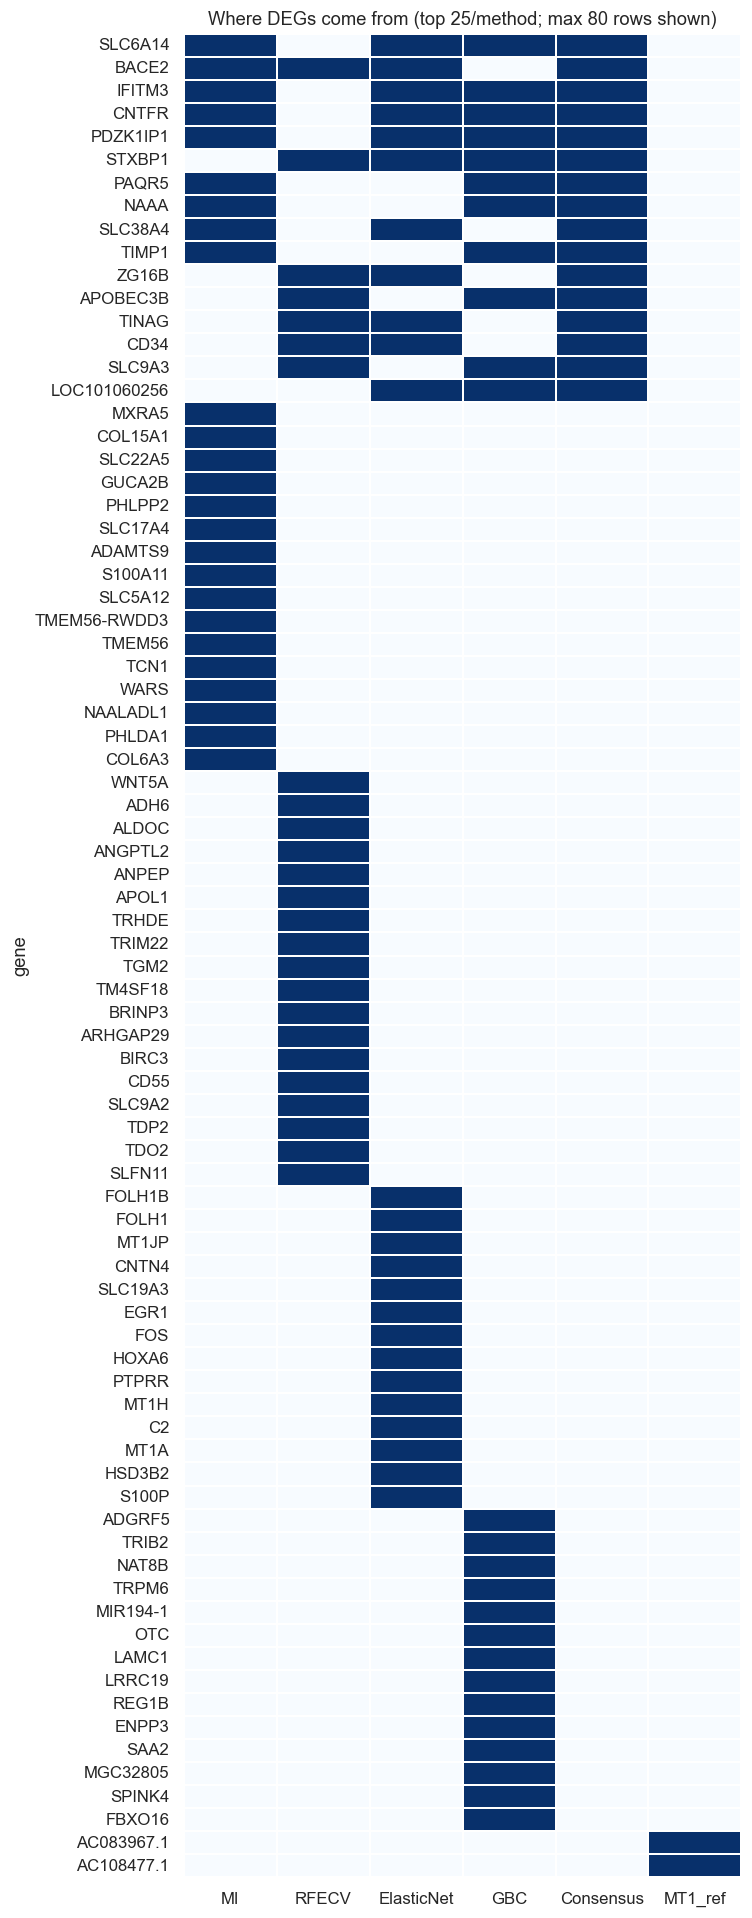


Merged pruned (|r|>0.82): 78 -> 40 (dropped 38)
Dropped (first 25): ['ADAMTS9', 'ADGRF5', 'ANGPTL2', 'ARHGAP29', 'BACE2', 'CD34', 'CD55', 'COL15A1', 'COL6A3', 'FOLH1', 'FOS', 'IFITM3', 'LAMC1', 'LOC101060256', 'LRRC19', 'MIR194-1', 'MT1A', 'MT1JP', 'NAAA', 'NAALADL1', 'NAT8B', 'OTC', 'PAQR5', 'PDZK1IP1', 'PHLDA1']
Merged unique gene list:


,gene
0,PAQR5
1,SLC6A14
2,NAAA
3,BACE2
4,IFITM3
...,...
73,ENPP3
74,SAA2
75,MGC32805
76,SPINK4


Saved: ..\04_Analysis\fs_merged_2_1.csv
Merged pruned gene list:


,gene
0,SLC6A14
1,MXRA5
2,CNTFR
3,SLC38A4
4,GUCA2B
5,SLC17A4
6,SLC5A12
7,TMEM56-RWDD3
8,TCN1
9,TIMP1


Saved: ..\04_Analysis\fs_merged_pruned_2_1.csv

Merged list with DGE stats:


,log2FC,FDR,direction,pruned_kept
gene,,,,
PAQR5,-1.9605,0.0000,down,False
SLC6A14,4.5331,0.0000,up,True
NAAA,-1.2886,0.0000,down,False
BACE2,1.3638,0.0000,up,False
IFITM3,1.2432,0.0000,up,False
...,...,...,...,...
ENPP3,-1.0777,0.0013,down,True
SAA2,2.6842,0.0000,up,False
MGC32805,-1.3189,0.0000,down,True



Midterm 1 reference overlap (not a replacement of the IBD panel):
MT1 genes: ['AC083967.1', 'AC108477.1', 'AC112777.1', 'AL356275.1', 'ARHGAP16P', 'CST4', 'SLC6A2', 'TRPM3']
MT1 ∩ merged: []
MT1 ∩ consensus: []
MT1 ∩ GSE75214 DEG matrix: []


In [7]:
from task2_1_lib import save_and_show

# Consensus (votes >= 2) stays the exam panel. Then A2-style merged + merged prune.
votes = Counter()
for s in [mi_sel, rfe_sel, en_sel, gb_sel]:
    votes.update(s)
panel = sorted([g for g, ct in votes.items() if ct >= 2], key=lambda g: -votes[g])

dge = pd.read_csv(OUT / "dge_table_2_1.csv", index_col=0)
ml = dge.reindex(panel)[["log2FC", "FDR", "direction"]].copy()
ml["n_methods"] = [votes[g] for g in panel]
ml["MI"] = [g in mi_sel for g in panel]
ml["RFECV"] = [g in rfe_sel for g in panel]
ml["ElasticNet"] = [g in en_sel for g in panel]
ml["GBC"] = [g in gb_sel for g in panel]
print("Consensus panel (votes >= 2):", len(panel))
print("Genes picked by 3+ methods:", int((ml["n_methods"] >= 3).sum()))
print("Consensus gene list:", ", ".join(panel))
save_and_show(ml, OUT / "ml_biomarkers_2_1.csv", title="Consensus vote table (Gene | MI | RFECV | EN | GBC | Votes):")

# --- A2 pattern: merged union of the four TOPN lists ---
method_sets = OrderedDict([
    ("MI", list(mi.head(TOPN).index)),
    ("RFECV", list(rfe_rank.head(TOPN).index)),
    ("ElasticNet", list(en_abs.head(TOPN).index)),
    ("GBC", list(gb_imp.head(TOPN).index)),
])
merged_unique_features = list(dict.fromkeys([g for lst in method_sets.values() for g in lst]))
print(f"\nMerged unique (union of top {TOPN} per method): {len(merged_unique_features)}")

# Membership map: where each DEG comes from
all_genes = merged_unique_features
member = pd.DataFrame(0, index=all_genes, columns=list(method_sets) + ["Consensus", "MT1_ref"])
for name, lst in method_sets.items():
    member.loc[lst, name] = 1
member.loc[[g for g in panel if g in member.index], "Consensus"] = 1

mt1_path = DATA / "midterm1_biomarkers.csv"
if mt1_path.exists():
    mt1_genes = pd.read_csv(mt1_path)["gene"].astype(str).tolist()
else:
    mt1_genes = []
for g in mt1_genes:
    if g not in member.index:
        member.loc[g] = 0
    member.loc[g, "MT1_ref"] = 1
member = member.fillna(0).astype(int)
member["n_fs_methods"] = member[["MI", "RFECV", "ElasticNet", "GBC"]].sum(axis=1)
member = member.sort_values(["n_fs_methods", "Consensus"], ascending=False)
save_and_show(member, OUT / "fs_membership_map_2_1.csv", title="Feature-selection membership map (1 = selected):")

fig, ax = plt.subplots(figsize=(7, max(6, 0.22 * min(len(member), 80))))
plot_m = member.drop(columns=["n_fs_methods"]).head(80)
sns.heatmap(plot_m, cmap="Blues", cbar=False, ax=ax, linewidths=0.2)
ax.set_title(f"Where DEGs come from (top {TOPN}/method; max 80 rows shown)")
ax.set_ylabel("gene")
fig.tight_layout()
fig.savefig(FIG / "task2_1_fs_membership.png", dpi=150)
plt.show()

# --- merged prune: drop one of each |r| > 0.82 pair, keep stronger |log2FC| ---
def prune_correlated_features(features, X_ref, threshold=0.82):
    feats = [f for f in features if f in X_ref.columns]
    if len(feats) < 2:
        return feats
    corr = X_ref[feats].corr().abs()
    drop = set()
    strength = dge.reindex(feats)["log2FC"].abs().fillna(0)
    for i, a in enumerate(feats):
        if a in drop:
            continue
        for b in feats[i + 1:]:
            if b in drop:
                continue
            if corr.loc[a, b] < threshold:
                continue
            sa = float(strength[a]) if a in strength.index else 0.0
            sb = float(strength[b]) if b in strength.index else 0.0
            drop.add(b if sa >= sb else a)
    return [f for f in feats if f not in drop]

X_ref = pd.DataFrame(X_train, columns=genes)
merged_pruned_features = prune_correlated_features(merged_unique_features, X_ref, 0.82)
dropped = sorted(set(merged_unique_features) - set(merged_pruned_features))
print(f"\nMerged pruned (|r|>0.82): {len(merged_unique_features)} -> {len(merged_pruned_features)} (dropped {len(dropped)})")
print("Dropped (first 25):", dropped[:25])
save_and_show(
    pd.DataFrame({"gene": merged_unique_features}),
    OUT / "fs_merged_2_1.csv",
    index=False,
    title="Merged unique gene list:",
)
save_and_show(
    pd.DataFrame({"gene": merged_pruned_features}),
    OUT / "fs_merged_pruned_2_1.csv",
    index=False,
    title="Merged pruned gene list:",
)

merged_view = dge.reindex(merged_unique_features)[["log2FC", "FDR", "direction"]].copy()
merged_view["pruned_kept"] = [g in set(merged_pruned_features) for g in merged_unique_features]
print("\nMerged list with DGE stats:")
display(merged_view.round(4))

# Midterm 1 as reference comparison only
print("\nMidterm 1 reference overlap (not a replacement of the IBD panel):")
print("MT1 genes:", mt1_genes)
print("MT1 ∩ merged:", sorted(set(mt1_genes) & set(merged_unique_features)))
print("MT1 ∩ consensus:", sorted(set(mt1_genes) & set(panel)))
print("MT1 ∩ GSE75214 DEG matrix:", sorted(set(mt1_genes) & set(genes)))


## 7b. ML consensus on the DGE volcano

This plot uses the same DGE axes as Notebook 1. Colour shows how many ML methods voted
for the gene. It combines statistical evidence (DGE) with predictive evidence (feature
selection). Genes with strong DGE and several votes are interesting candidates. They still
need independent validation.


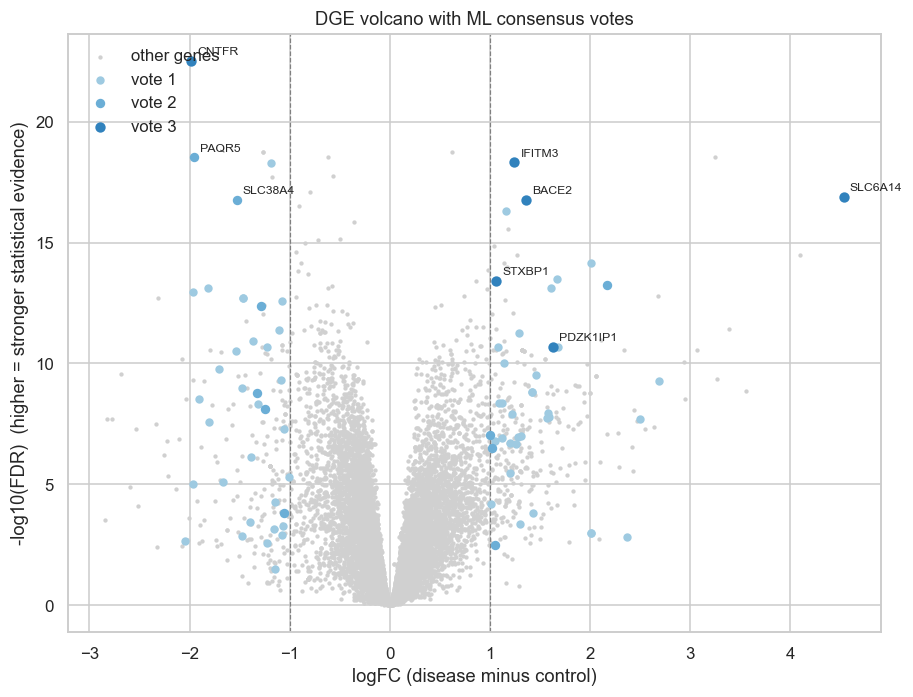

Vote counts on this volcano: {0: np.int64(21069), 1: np.int64(62), 2: np.int64(10), 3: np.int64(6)}
Labelled high-vote genes that are not DEGs: []


In [8]:
# Overlay ML votes on the existing DGE volcano. Do not force non-DEGs into DEG colours.
dge_volc = pd.read_csv(OUT / "dge_table_2_1.csv", index_col=0)
fig, ax = plt.subplots(figsize=(8.5, 6.5))
fdr = dge_volc["FDR"].clip(lower=1e-300)
x = dge_volc["log2FC"]
yv = -np.log10(fdr)
vote_col = pd.Series(0, index=dge_volc.index)
for g, v in votes.items():
    if g in vote_col.index:
        vote_col.loc[g] = int(v)
ax.scatter(x, yv, c="#d0d0d0", s=8, linewidths=0, label="other genes")
palette = {1: "#9ecae1", 2: "#6baed6", 3: "#3182bd", 4: "#08519c"}
for k in [1, 2, 3, 4]:
    mask = vote_col == k
    if mask.any():
        ax.scatter(x[mask], yv[mask], c=palette[k], s=22 + 8 * k, linewidths=0, label=f"vote {k}", zorder=3)
to_label = [g for g, _v in votes.most_common(8) if g in dge_volc.index]
for g in to_label:
    ax.annotate(g, (x.loc[g], yv.loc[g]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axvline(1, color="grey", ls="--", lw=0.8)
ax.axvline(-1, color="grey", ls="--", lw=0.8)
ax.set_xlabel("logFC (disease minus control)")
ax.set_ylabel("-log10(FDR)  (higher = stronger statistical evidence)")
ax.set_title("DGE volcano with ML consensus votes")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(FIG / "task2_1_ml_consensus_volcano.png", dpi=150)
plt.show()
print("Vote counts on this volcano:", dict(vote_col.value_counts().sort_index()))
if "DEG" in dge_volc.columns:
    not_deg = [g for g in to_label if not bool(dge_volc.loc[g, "DEG"])]
    print("Labelled high-vote genes that are not DEGs:", not_deg)


Grey points are genes with no TOPN vote. Darker blue means more methods agreed.
A gene on the far right or left with many votes has both a large expression change and ML
support. If a voted gene is not a DEG, the plot still shows it honestly. We do not treat
these points as a finished diagnostic test.


## 8. Does the balancing method change the panel


In [9]:
# The exam asks us to address the balance issue with the teamwork techniques. To show
# why the choice matters, we rebuild the panel with the Midterm 1 style undersampling and
# compare it with the SMOTE panel above.
def build_panel(Xm, ym, genes, topn=50):
    """Run the four feature selection methods and return the consensus gene set."""
    Xsc = StandardScaler().fit_transform(Xm)
    mi_s = set(pd.Series(mutual_info_classif(Xm, ym, random_state=RNG), index=genes).sort_values(ascending=False).head(topn).index)
    r = RFECV(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG),
              step=25, cv=StratifiedKFold(5, shuffle=True, random_state=RNG),
              scoring="roc_auc", min_features_to_select=10, n_jobs=1).fit(Xsc, ym)
    r_s = set(pd.Series(r.ranking_, index=genes).sort_values().head(topn).index)
    e = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5, C=0.1,
                           max_iter=5000, class_weight="balanced", random_state=RNG).fit(Xsc, ym)
    e_s = set(pd.Series(np.abs(e.coef_[0]), index=genes).sort_values(ascending=False).head(topn).index)
    g = GradientBoostingClassifier(random_state=RNG).fit(Xm, ym)
    g_s = set(pd.Series(g.feature_importances_, index=genes).sort_values(ascending=False).head(topn).index)
    v = Counter()
    for s in [mi_s, r_s, e_s, g_s]:
        v.update(s)
    return set(gg for gg, ct in v.items() if ct >= 2)

np.random.seed(RNG)
dis = np.where(y == 1)[0]
ctr = np.where(y == 0)[0]
keep = np.concatenate([ctr, np.random.choice(dis, size=len(ctr), replace=False)])
under_panel = build_panel(X.values[keep], y[keep], genes)
smote_panel = set(panel)
inter = smote_panel & under_panel
jac = len(inter) / len(smote_panel | under_panel)
print("SMOTE panel size        :", len(smote_panel))
print("Undersampling panel size:", len(under_panel))
print("Shared genes            :", len(inter))
print("Jaccard overlap         :", round(jac, 3))

SMOTE panel size        : 16
Undersampling panel size: 48
Shared genes            : 7
Jaccard overlap         : 0.123


SMOTE and undersampling do not pick the same genes. With only 22 real controls,
the list is sensitive to how we balance. We prefer SMOTE here because it keeps all 172
disease samples in train. We cannot say one list is the true biology list.


## Limitations

Feature selection runs on the same GSE75214 DEG matrix that we later evaluate. Votes
support a gene as a candidate; they do not prove it is a biomarker. A gene can help
prediction without being one of the strongest DEGs, because statistical significance
and predictive importance answer different questions.

## Notebook 2 summary

We selected genes with MI, RFECV, Elastic Net and GBC, then voted. The consensus panel is
the exam ML list. Merged / merged pruned are extra A2-style lists. Midterm 1 overlap is 0
because that panel was built for breast cancer, not because Midterm 1 was wrong.

Oral-defense questions are consolidated in `2_0_final_overview.ipynb` (section **Oral defense**).
